In [14]:
# === BarkNet-AMIL notebook — IMPORTS (standard block; append here as we add visuals) ===
import os
import sys
import math
import yaml
import random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import cv2
from PIL import Image
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

# NOTE: `helper.*` imports live in the CONFIG block (they need PROJECT_ROOT on sys.path).

In [15]:
# === CONFIGURATION (standard block; update whenever a viz needs a new path/param) ===

# --- 1. Project location — EDIT THIS to your machine ---
PROJECT_ROOT = Path(r"G:\Source\BarkNet_ML\BarkNet_ML")
CONFIG_PATH  = PROJECT_ROOT / "config" / "config.yaml"

# Make the `helper` package importable from the notebook, then import it.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import helper.data_loader as dt
from helper.model_wrapper import ConvNeXtAMIL

# --- 2. Load the training config ---
with open(CONFIG_PATH, "r") as f:
    cfg = yaml.safe_load(f)

# config.yaml stores relative paths (./runs, ./data); resolve them against PROJECT_ROOT.
def rel(p):
    p = Path(p)
    return p if p.is_absolute() else (PROJECT_ROOT / p)

# --- 3. Core fields ---
SEED    = cfg["project"].get("seed", 42)
DEVICE  = cfg["project"]["device"] if torch.cuda.is_available() else "cpu"
SPECIES = cfg["data"]["species"]
SIZE    = str(cfg["model"]["size"]).lower()
AUG     = cfg["augmentation"]

# --- 4. Data paths ---
PATCH_ROOT     = rel(cfg["data"]["patch_root"])   # Stage-1/2 TRAIN patches
TEST_DATA_ROOT = rel(cfg["test"]["data_root"])    # TEST patches

# --- 5. Run / output directories ---
PRETRAIN_DIR = rel(cfg["pretrain"]["output_dir"])
TRAIN_DIR    = rel(cfg["train"]["output_dir"])
TEST_DIR     = rel(cfg["test"]["output_dir"])
TUNE_DIR     = rel(cfg["tune"]["output_dir"])

# --- 6. Result files each stage writes ---
PRETRAIN_CSV = PRETRAIN_DIR / "pretrain_results.csv"            # Stage-1 curves
TRAIN_CSV    = TRAIN_DIR / f"convnext_{SIZE}_results.csv"       # Stage-2 curves
TEST_XLSX    = r"G:\Source\BarkNet_ML\BarkNet_ML\runs\testing\barknetTestRun_pico_224\test\classification_results.xlsx"      # test report

# --- 7. Checkpoints ---
BACKBONE_CKPT = rel(cfg["model"].get("backbone_checkpoint") or (PRETRAIN_DIR / "best_backbone.pth"))
MODEL_CKPT    = rel(cfg["test"].get("checkpoint")          or (TRAIN_DIR / "best_model.pth"))

# --- 8. Notebook behaviour knobs (flip to skip the expensive steps) ---
BUILD_LOADERS = True   # False -> skip the ~2.9M-patch disk scan in the DATA block
LOAD_MODEL    = True   # False -> skip checkpoint loading (e.g. before any run exists)

# --- 9. Plot defaults ---
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

# --- 10. Availability report — tells you what's runnable right now ---
print(f"{'device':<15}: {DEVICE}   |  size: {SIZE}  |  classes: {len(SPECIES)}")
for label, p in [("patch_root", PATCH_ROOT), ("test_data", TEST_DATA_ROOT),
                 ("stage1 csv", PRETRAIN_CSV), ("stage2 csv", TRAIN_CSV),
                 ("test xlsx", TEST_XLSX), ("backbone ckpt", BACKBONE_CKPT),
                 ("model ckpt", MODEL_CKPT)]:
    print(f"  [{'ok' if p.exists() else '--'}] {label:<14} {p}")

device         : cuda:0   |  size: pico  |  classes: 20
  [ok] patch_root     G:\Source\BarkNet_ML\BarkNet_ML\data\barknet\patches_224\train
  [--] test_data      G:\Source\BarkNet_ML\BarkNet_ML\data\barknet_patches\test
  [--] stage1 csv     G:\Source\BarkNet_ML\BarkNet_ML\runs\pretrain\pretrain_results.csv
  [--] stage2 csv     G:\Source\BarkNet_ML\BarkNet_ML\runs\train\convnext_pico_results.csv


AttributeError: 'str' object has no attribute 'exists'

In [8]:
# === DATA (standard block) — scan the patch tree ONCE, reuse everywhere ===
# split_by_tree() walks the whole patch_root (~2.9M files) — the one slow step.
# We cache (train_bags, val_bags) in the namespace and skip re-scanning on re-run.
# Each bag is a list of (patch_path, label) for one image = exactly what the
# data-prep visuals need (class counts, bag-size distributions, sample patches),
# with no model required.

FORCE_RESCAN = True

if BUILD_LOADERS and (FORCE_RESCAN or "train_bags" not in globals()):
    train_bags, val_bags = dt.split_by_tree(
        patch_root=str(PATCH_ROOT),
        species=SPECIES,
        fcfg=cfg["data"].get("filename", {}),
        val_ratio=cfg["data"]["val_ratio"],
        seed=SEED,
    )
    print(f"Cached split: {len(train_bags)} train / {len(val_bags)} val image-bags.")
elif not BUILD_LOADERS:
    print("BUILD_LOADERS=False — skipped disk scan (data-prep visuals unavailable).")
else:
    print(f"Reusing cached split: {len(train_bags)} train / {len(val_bags)} val bags.")


# --- On-demand loaders built FROM the cached bags (no re-scan) ---
# num_workers=0 on purpose: Windows + Jupyter + spawn-based workers is fragile.
def stage2_loaders_from_cache(cap=True, shuffle_train=True):
    """Stage-2 AMIL loaders (batch_size = 1 bag). cap=True mirrors training by
    applying max_patches_per_bag; cap=False shows the true uncapped bags."""
    mp = cfg["data"].get("max_patches_per_bag") if cap else None
    tb = dt._cap_bags(train_bags, mp, SEED) if mp else train_bags
    vb = dt._cap_bags(val_bags,   mp, SEED) if mp else val_bags
    tl = DataLoader(dt.PatchBagDataset(tb, dt.build_train_transform(AUG)),
                    batch_size=1, shuffle=shuffle_train, num_workers=0)
    vl = DataLoader(dt.PatchBagDataset(vb, dt.build_eval_transform(AUG)),
                    batch_size=1, shuffle=False, num_workers=0)
    return tl, vl

def stage1_loaders_from_cache(batch_size=None):
    """Stage-1 flat per-patch loaders (standard mini-batches)."""
    bs = batch_size or cfg["pretrain"]["batch_size"]
    tp, vp = dt.flatten_bags(train_bags), dt.flatten_bags(val_bags)
    tl = DataLoader(dt.PatchDataset(tp, dt.build_train_transform(AUG)),
                    batch_size=bs, shuffle=True, num_workers=0, drop_last=True)
    vl = DataLoader(dt.PatchDataset(vp, dt.build_eval_transform(AUG)),
                    batch_size=bs, shuffle=False, num_workers=0)
    return tl, vl

Scanning patches and grouping by tree -> image ...
Split complete: 15982 train images / 2566 val images across 799 trees.
Cached split: 15982 train / 2566 val image-bags.


In [ ]:
# === MODEL (standard block) — load a checkpoint ONCE, reuse across visuals ===
# weights="none" builds the backbone WITHOUT downloading ImageNet (offline-safe);
# all weights come from the checkpoint. Stage-2 -> AMIL model (attention weights
# available for heatmaps); Stage-1 -> plain backbone classifier.

FORCE_RELOAD_MODEL = False
MODEL_STAGE = "stage2"   # "stage2" (best_model.pth) | "stage1" (best_backbone.pth)

def _load_model():
    if MODEL_STAGE == "stage2":
        ckpt = MODEL_CKPT
        wrapper = ConvNeXtAMIL(device=DEVICE, species=SPECIES, model_size=SIZE,
                               weights="none",
                               pretrained_checkpoint=str(ckpt) if ckpt.exists() else None,
                               save_data=False)
        m, _ = wrapper.get_model()
    else:
        ckpt = BACKBONE_CKPT
        wrapper = ConvNeXtAMIL(device=DEVICE, species=SPECIES, model_size=SIZE,
                               weights="none",
                               backbone_checkpoint=str(ckpt) if ckpt.exists() else None,
                               save_data=False)
        m, _ = wrapper.get_patch_model()
    m.eval()
    return wrapper, m, ckpt

_target_ckpt = MODEL_CKPT if MODEL_STAGE == "stage2" else BACKBONE_CKPT

if LOAD_MODEL and (FORCE_RELOAD_MODEL or "model" not in globals()):
    if not _target_ckpt.exists():
        print(f"No {MODEL_STAGE} checkpoint at {_target_ckpt}\n"
              f"  -> set LOAD_MODEL=False, or switch MODEL_STAGE, once a run exists.")
    else:
        wrapper, model, LOADED_CKPT = _load_model()
        n_params = sum(p.numel() for p in model.parameters())
        print(f"Loaded {MODEL_STAGE} model ({n_params/1e6:.1f}M params) "
              f"from {LOADED_CKPT} on {DEVICE}.")
elif not LOAD_MODEL:
    print("LOAD_MODEL=False — skipped model load.")
else:
    print(f"Reusing already-loaded model ({MODEL_STAGE}).")

## Data Preparation

### Patch Grid

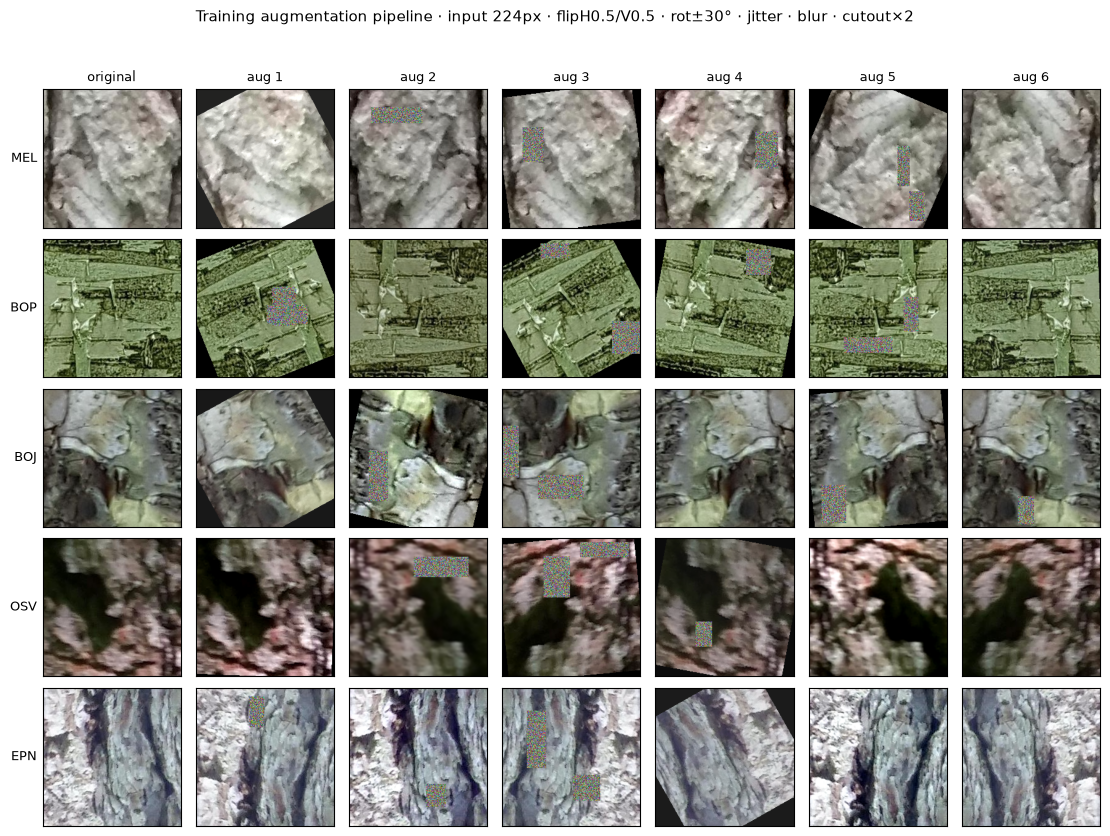

In [12]:
# === VIZ 2: augmentation pipeline preview (random augments per source patch) ===
# Pulls real patches, pushes each through the EXACT training transform several times,
# and lays them in a grid. Column 0 is the deterministic reference (resize+normalize,
# no random ops); columns 1..N are independent random draws of the full pipeline.
assert "train_bags" in globals(), "Run the DATA block first (BUILD_LOADERS=True)."

N_SOURCES = 5     # distinct source patches (rows)
N_AUGS    = 6     # random augmentations per patch (columns after 'original')

train_tf = dt.build_train_transform(AUG)   # flip/rotate/jitter/blur/cutout + normalize
eval_tf  = dt.build_eval_transform(AUG)    # resize + normalize only (reference column)

# De-normalize a [3,H,W] tensor back to a displayable [H,W,3] array in [0,1].
_mean = torch.tensor(AUG["normalize"]["mean"]).view(3, 1, 1)
_std  = torch.tensor(AUG["normalize"]["std"]).view(3, 1, 1)
def denorm(t):
    return (t * _std + _mean).clamp(0, 1).permute(1, 2, 0).numpy()

def load_patch(path):                       # identical to PatchDataset.__getitem__
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    return Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))

# Pick N_SOURCES patches from distinct bags (reproducible via SEED).
rng = random.Random(SEED)
chosen = rng.sample(train_bags, min(N_SOURCES, len(train_bags)))
sources = [(rng.choice(b)[0], SPECIES[b[0][1]]) for b in chosen]

torch.manual_seed(SEED)                     # fixes the random draws so the figure is stable
fig, axes = plt.subplots(N_SOURCES, N_AUGS + 1,
                         figsize=(1.6 * (N_AUGS + 1), 1.7 * N_SOURCES))
axes = np.atleast_2d(axes)                  # keep 2-D even if N_SOURCES == 1

for r, (path, name) in enumerate(sources):
    pil = load_patch(path)
    axes[r, 0].imshow(denorm(eval_tf(pil)))
    axes[r, 0].set_ylabel(name, fontsize=9, rotation=0, ha="right", va="center")
    for c in range(1, N_AUGS + 1):
        axes[r, c].imshow(denorm(train_tf(pil)))   # fresh random draw each call
    for c in range(N_AUGS + 1):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

for c in range(N_AUGS + 1):
    axes[0, c].set_title("original" if c == 0 else f"aug {c}", fontsize=9)

_re = AUG.get("random_erasing", {})
fig.suptitle(
    f"Training augmentation pipeline · input {AUG['input_size']}px · "
    f"flipH{AUG.get('horizontal_flip',0)}/V{AUG.get('vertical_flip',0)} · "
    f"rot±{AUG.get('rotation',{}).get('degrees','-')}° · jitter · blur · "
    f"cutout×{_re.get('count',0)}",
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Data Distribution

,Species,Trees,Images,Patches,Avg patches/image
0,MEL,62,"1,527","465,240",304.7
1,CHR,87,"2,207","325,311",147.4
2,ERS,65,"1,528","277,932",181.9
3,PET,46,833,"252,494",303.1
4,ERR,51,"1,393","224,069",160.9
5,FRA,49,"1,074","202,192",188.3
6,EPN,35,703,"174,062",247.6
7,BOJ,34,"1,027","161,428",157.2
8,BOP,26,"1,085","153,025",141.0
9,EPO,58,"1,070","149,757",140.0


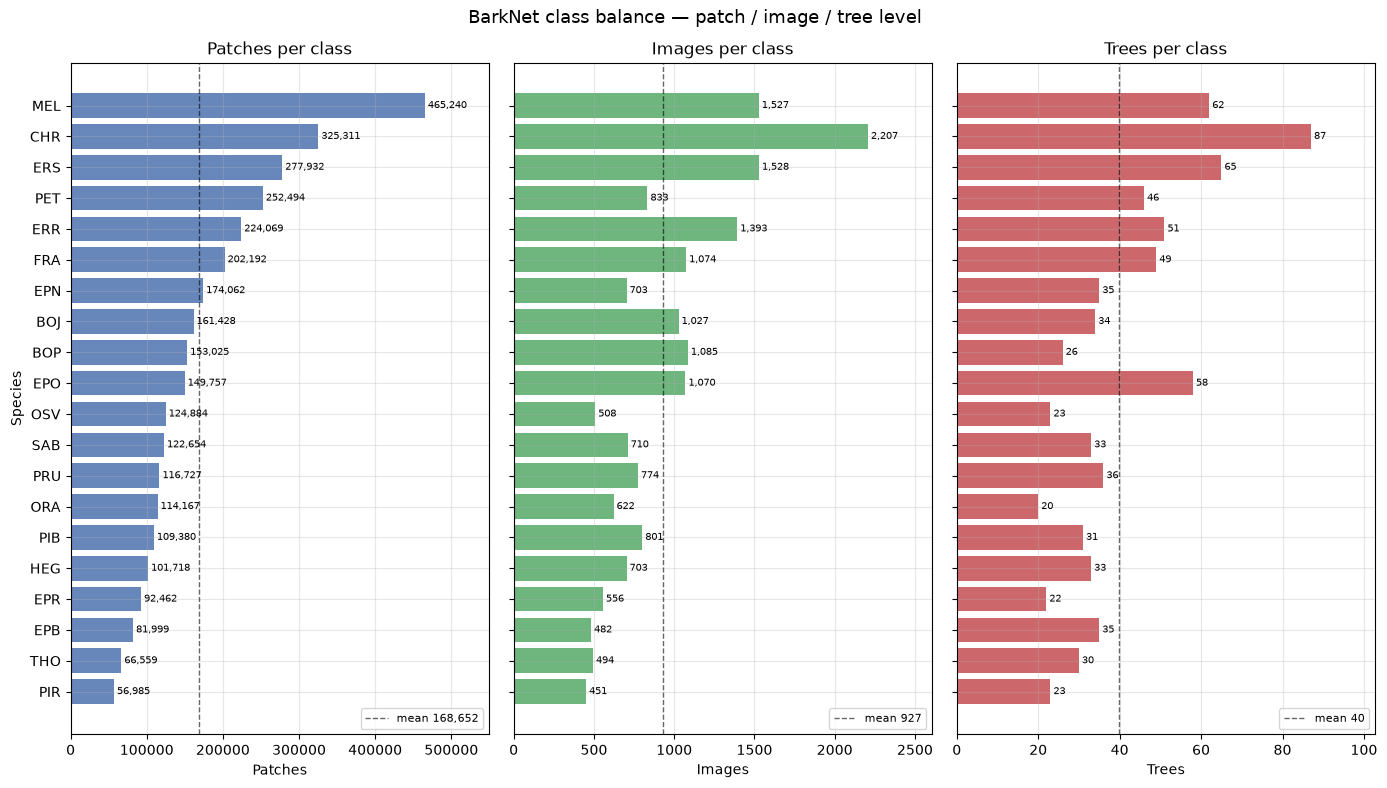


Patch-level imbalance  max/min = 8.2x  (MEL 465,240  vs  PIR 56,985)
Dataset totals: 799 trees, 18,548 images, 3,373,045 patches


In [9]:
# Uses the cached tree-level split. train_bags + val_bags = every image under
# PATCH_ROOT. Patch counts are UNCAPPED (true on-disk distribution, not the
# max_patches_per_bag view the Stage-2 loader sees).
assert "train_bags" in globals(), "Run the DATA block first (BUILD_LOADERS=True)."

fcfg     = cfg["data"].get("filename", {})
all_bags = train_bags + val_bags

patches_per_class = defaultdict(int)
images_per_class  = defaultdict(int)
trees_per_class   = defaultdict(set)

for b in all_bags:
    label = b[0][1]
    images_per_class[label]  += 1
    patches_per_class[label] += len(b)
    tree_id, _ = dt._parse_ids(b[0][0].name, fcfg)   # tree id from the bag's filename
    trees_per_class[label].add(tree_id)

# --- Summary table (per class + compiled ALL row) ---
rows = []
for label, name in enumerate(SPECIES):
    n_img, n_pat = images_per_class[label], patches_per_class[label]
    rows.append({
        "Species": name,
        "Trees":   len(trees_per_class[label]),
        "Images":  n_img,
        "Patches": n_pat,
        "Avg patches/image": (n_pat / n_img) if n_img else 0.0,
    })

dist_df = pd.DataFrame(rows).sort_values("Patches", ascending=False).reset_index(drop=True)

tot_img, tot_pat = int(dist_df["Images"].sum()), int(dist_df["Patches"].sum())
total_row = {
    "Species": "ALL",
    "Trees":   int(dist_df["Trees"].sum()),
    "Images":  tot_img,
    "Patches": tot_pat,
    "Avg patches/image": (tot_pat / tot_img) if tot_img else 0.0,   # weighted, not mean-of-means
}
dist_table = pd.concat([dist_df, pd.DataFrame([total_row])], ignore_index=True)

_styled = (dist_table.style
           .format({"Trees": "{:,}", "Images": "{:,}", "Patches": "{:,}",
                    "Avg patches/image": "{:.1f}"})
           .set_caption("BarkNet class distribution — train+val, uncapped patches"))
try:
    from IPython.display import display
    display(_styled)
except Exception:
    print(dist_table.to_string(index=False))

# --- Figure: 3 panels, shared class order, sorted by patch count ---
order   = dist_df["Species"].tolist()
y       = np.arange(len(order))
metrics = [("Patches", "#4C72B0"), ("Images", "#55A868"), ("Trees", "#C44E52")]

fig, axes = plt.subplots(1, 3, figsize=(14, 8), sharey=True)
for ax, (col, color) in zip(axes, metrics):
    vals = dist_df[col].to_numpy()
    ax.barh(y, vals, color=color, alpha=0.85)
    ax.axvline(vals.mean(), ls="--", lw=1, color="k", alpha=0.6, label=f"mean {vals.mean():,.0f}")
    for yi, v in zip(y, vals):
        ax.text(v, yi, f" {v:,.0f}", va="center", ha="left", fontsize=7)
    ax.set_title(f"{col} per class"); ax.set_xlabel(col)
    ax.legend(loc="lower right", fontsize=8); ax.margins(x=0.18)

axes[0].set_yticks(y); axes[0].set_yticklabels(order)
axes[0].set_ylabel("Species"); axes[0].invert_yaxis()          # largest class at top
fig.suptitle("BarkNet class balance — patch / image / tree level", fontsize=13)
fig.tight_layout(); plt.show()

# --- Imbalance callout ---
pat = dist_df["Patches"]
print(f"\nPatch-level imbalance  max/min = {pat.max() / max(pat.min(), 1):.1f}x  "
      f"({dist_df.iloc[0]['Species']} {pat.max():,}  vs  "
      f"{dist_df.iloc[-1]['Species']} {pat.min():,})")
print(f"Dataset totals: {total_row['Trees']} trees, {tot_img:,} images, {tot_pat:,} patches")

## Training

### Training curves

In [ ]:
# === VIZ 3: training curves (loss / accuracy / learning rate) from a results CSV ===
# Both training scripts log the same schema:
#   epoch, train_loss, train_acc, val_loss, val_acc, learning_rate
# The 'monitor' marks the epoch each script actually checkpoints on:
#   Stage 1 -> best val_loss (min) ; Stage 2 -> best val_acc (max).
_CURVE_COLS = ["epoch", "train_loss", "train_acc", "val_loss", "val_acc", "learning_rate"]

def plot_training_curves(csv_path, title, monitor=("val_loss", "min")):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        print(f"[skip] no CSV at {csv_path}"); return None
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        print(f"[skip] {csv_path.name} has no rows yet (no epoch logged)."); return None
    missing = [c for c in _CURVE_COLS if c not in df.columns]
    if missing:
        print(f"[skip] {csv_path.name} missing columns: {missing}"); return None

    ep = df["epoch"]
    mcol, mmode = monitor
    best_idx = df[mcol].idxmin() if mmode == "min" else df[mcol].idxmax()
    best_ep  = int(df.loc[best_idx, "epoch"])
    best_val = float(df.loc[best_idx, mcol])

    fig, (aL, aA, aR) = plt.subplots(1, 3, figsize=(15, 4.5))

    aL.plot(ep, df["train_loss"], "-o", ms=3, label="train")
    aL.plot(ep, df["val_loss"],   "-o", ms=3, label="val")
    aL.set_title("Loss"); aL.set_xlabel("epoch"); aL.set_ylabel("loss")

    aA.plot(ep, df["train_acc"], "-o", ms=3, label="train")
    aA.plot(ep, df["val_acc"],   "-o", ms=3, label="val")
    aA.set_title("Accuracy"); aA.set_xlabel("epoch"); aA.set_ylabel("accuracy (%)")

    aR.plot(ep, df["learning_rate"], "-o", ms=3, color="#8172B3")
    aR.set_title("Learning rate (warmup → cosine)"); aR.set_xlabel("epoch"); aR.set_ylabel("lr")

    # Highlight the checkpoint-selection epoch on the monitored panel + all panels.
    tgt = aL if mcol.endswith("loss") else aA
    tgt.plot(best_ep, best_val, "*", ms=16, color="crimson", zorder=5, label=f"best @ ep {best_ep}")
    for ax in (aL, aA, aR):
        ax.axvline(best_ep, ls="--", lw=1, color="k", alpha=0.4)
    aL.legend(); aA.legend()

    bstr = f"{best_val:.4f}" if mcol.endswith("loss") else f"{best_val:.2f}%"
    fig.suptitle(f"{title}   —   best {mcol}={bstr} @ epoch {best_ep}   "
                 f"(final val_acc={df['val_acc'].iloc[-1]:.2f}%)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()
    return df

# Plot whichever stages have logged results.
s1_df = plot_training_curves(PRETRAIN_CSV, f"Stage 1 · backbone pretrain (convnext_{SIZE})",
                             monitor=("val_loss", "min"))
s2_df = plot_training_curves(TRAIN_CSV,    f"Stage 2 · AMIL fine-tune (convnext_{SIZE})",
                             monitor=("val_acc", "max"))

## Results

### Confusion Matrix

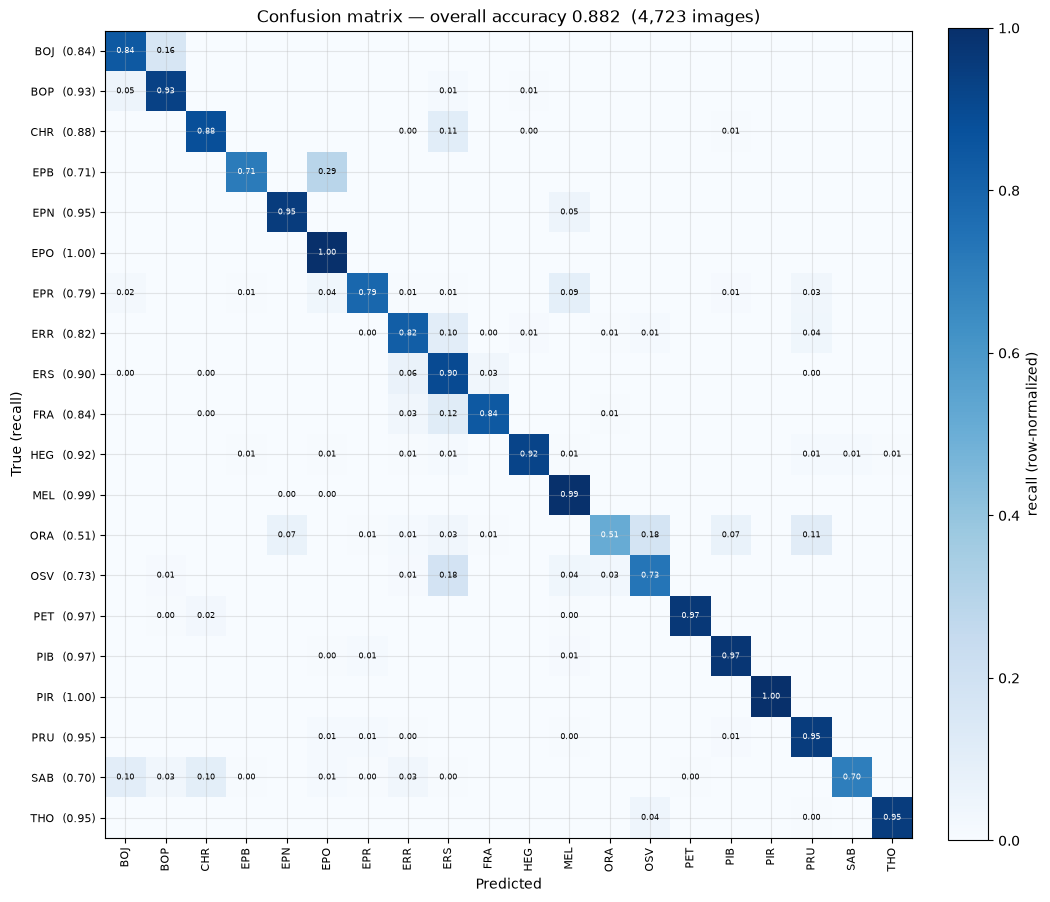

,Species,Recall,Precision,Support
0,ORA,0.510,0.902,145
1,SAB,0.698,0.987,212
2,EPB,0.711,0.964,114
3,OSV,0.731,0.650,104
4,EPR,0.788,0.942,184
5,ERR,0.823,0.820,283
6,BOJ,0.842,0.838,228
7,FRA,0.842,0.957,398
8,CHR,0.882,0.942,517
9,ERS,0.896,0.681,383


In [16]:
# === VIZ 4: confusion matrix from the test-set results ===
# test_model.py writes an Excel workbook (classification_results.xlsx) with one sheet
# per species (per-image rows) plus 'Confusion_Matrix' and 'Performance_Metrics' sheets.
# We reconstruct the CM from the per-image predictions (also accepts a flat predictions
# CSV with true_class / predicted_class columns), so we control normalization + metrics.

def load_test_predictions(path):
    """Return a DataFrame of per-image predictions (true_class, predicted_class)."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No test results at {path} — run test_model.py first.")
    if path.suffix.lower() in (".xlsx", ".xls"):
        sheets = pd.read_excel(path, sheet_name=None)
        frames = [df for name, df in sheets.items()
                  if name not in ("Confusion_Matrix", "Performance_Metrics")
                  and {"true_class", "predicted_class"}.issubset(df.columns)]
        if not frames:
            raise ValueError(f"No per-image prediction sheets found in {path.name}")
        return pd.concat(frames, ignore_index=True)
    return pd.read_csv(path)

def confusion_report(path=TEST_XLSX, species=SPECIES, normalize="true", annotate=True):
    """Plot the confusion matrix and return (cm_counts, per_class_metrics_df, overall_acc).
    normalize='true' colours by per-true-class recall; normalize=None colours by counts."""
    try:
        pred = load_test_predictions(path)
    except (FileNotFoundError, ValueError) as e:
        print(f"[skip] {e}"); return None

    yt = pred["true_class"].astype(str)
    yp = pred["predicted_class"].astype(str)
    cm = confusion_matrix(yt, yp, labels=species)
    n  = len(species)

    row, col = cm.sum(1, keepdims=True), cm.sum(0)
    cmn = np.divide(cm, row, out=np.zeros(cm.shape, dtype=float), where=row != 0)
    recall = np.divide(np.diag(cm), cm.sum(1), out=np.zeros(n), where=cm.sum(1) != 0)
    prec   = np.divide(np.diag(cm), col,        out=np.zeros(n), where=col != 0)
    overall = np.trace(cm) / max(cm.sum(), 1)

    disp = cmn if normalize == "true" else cm.astype(float)
    vmax = 1.0 if normalize == "true" else max(disp.max(), 1)

    fig, ax = plt.subplots(figsize=(1.0 + 0.48 * n, 0.9 + 0.48 * n))
    im = ax.imshow(disp, cmap="Blues", vmin=0, vmax=vmax)
    if annotate:
        for i in range(n):
            for j in range(n):
                if cm[i, j] == 0:
                    continue
                txt = f"{cmn[i, j]:.2f}" if normalize == "true" else f"{int(cm[i, j])}"
                hi = disp[i, j] > vmax * 0.5
                ax.text(j, i, txt, ha="center", va="center", fontsize=6,
                        color="white" if hi else "black")

    ax.set_xticks(range(n)); ax.set_xticklabels(species, rotation=90, fontsize=8)
    ylab = [f"{s}  ({recall[i]:.2f})" for i, s in enumerate(species)] if normalize == "true" else species
    ax.set_yticks(range(n)); ax.set_yticklabels(ylab, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True" + (" (recall)" if normalize == "true" else ""))
    ax.set_title(f"Confusion matrix — overall accuracy {overall:.3f}  ({cm.sum():,} images)")
    fig.colorbar(im, fraction=0.046, pad=0.04,
                 label="recall (row-normalized)" if normalize == "true" else "count")
    fig.tight_layout(); plt.show()

    metrics = pd.DataFrame({"Species": species, "Recall": recall.round(3),
                            "Precision": prec.round(3), "Support": cm.sum(1)}) \
                .sort_values("Recall").reset_index(drop=True)
    return cm, metrics, overall

# Row-normalized view (best for imbalanced classes); pass normalize=None for raw counts.
_result = confusion_report(TEST_XLSX, SPECIES, normalize="true")
if _result is not None:
    cm_counts, cm_metrics, overall_acc = _result
    try:
        from IPython.display import display
        display(cm_metrics.style.format({"Recall": "{:.3f}", "Precision": "{:.3f}",
                                         "Support": "{:,}"})
                          .set_caption("Per-class metrics (sorted by recall — worst first)"))
    except Exception:
        print(cm_metrics.to_string(index=False))